# Análisis Exploratorio de Datos (EDA)

Este notebook presenta un análisis de la red hospitalaria y las trayectorias de pacientes, respondiendo a los objetivos planteados.

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../scripts"))

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import bases

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Cargar datos
print("Cargando datos principales...")
df_pacientes = bases.cargar_datos_pacientes("../data/pacientes.xlsx")
traslados = bases.reconstruir_traslados(df_pacientes)
print("Pacientes y traslados cargados.")

print("Cargando datos geográficos...")
hosp_coords = bases.cargar_coordenadas("../data/hospitales_coordenadas.csv")
municipios_amba = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")
municipios_amba = municipios_amba[municipios_amba["nam_limpio"].isin([
    "LA PLATA", "AVELLANEDA", "GENERAL SAN MARTIN", "HURLINGHAM", "ITUZAINGO", 
    "JOSE C PAZ", "LANUS", "LOMAS DE ZAMORA", "MALVINAS ARGENTINAS", "MORON", 
    "QUILMES", "SAN ISIDRO", "SAN MIGUEL", "TRES DE FEBRERO", "VICENTE LOPEZ", 
    "TIGRE", "ALMIRANTE BROWN", "BERAZATEGUI", "ESTEBAN ECHEVERRIA", "EZEIZA", 
    "FLORENCIO VARELA", "LA MATANZA", "MERLO", "MORENO", "SAN FERNANDO",
    "CIUDAD AUTONOMA DE BUENOS AIRES"
])]
print("Datos geográficos cargados.")

Cargando datos principales...


Pacientes y traslados cargados.
Cargando datos geográficos...


Datos geográficos cargados.


## 1. Funcionamiento de la Red General (AMBA)

### 1.1 Mapa con los hospitales y sus municipios alrededor

Ignorados (no encontrados en hosp_coords): {'MODULO HOSPITALARIO    AB'}


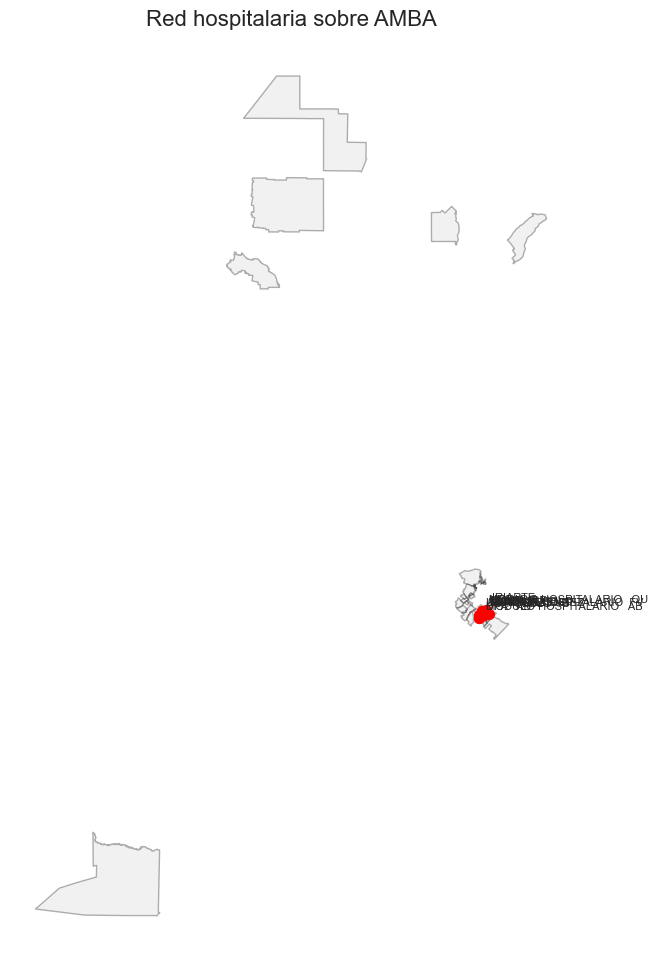

In [3]:
# Generar red
G, edges = bases.analizar_red_hospitalaria(
    traslados, hosp_coords, 
    peso_minimo=1, 
    modo="estatico", 
    mostrar_resumen=False, 
    graficar=False
)

# Convertir red y nodos a GeoDataFrames
gdf_edges, gdf_nodes = bases.gdf_red_hospitalaria(G, hosp_coords)

# Graficar
bases.plot_red_sobre_amba(gdf_edges, gdf_nodes, municipios_amba, mostrar_nombres=True, mostrar_peso=False)

### 1.2 Total de traslados

In [4]:
# Resumen de traslados
res_tras = bases.resumen_traslados(traslados, imprimir=True)

Total de traslados: 496
Cantidad de hospitales únicos: 12


### 1.3 Cantidad de traslados en función del tiempo

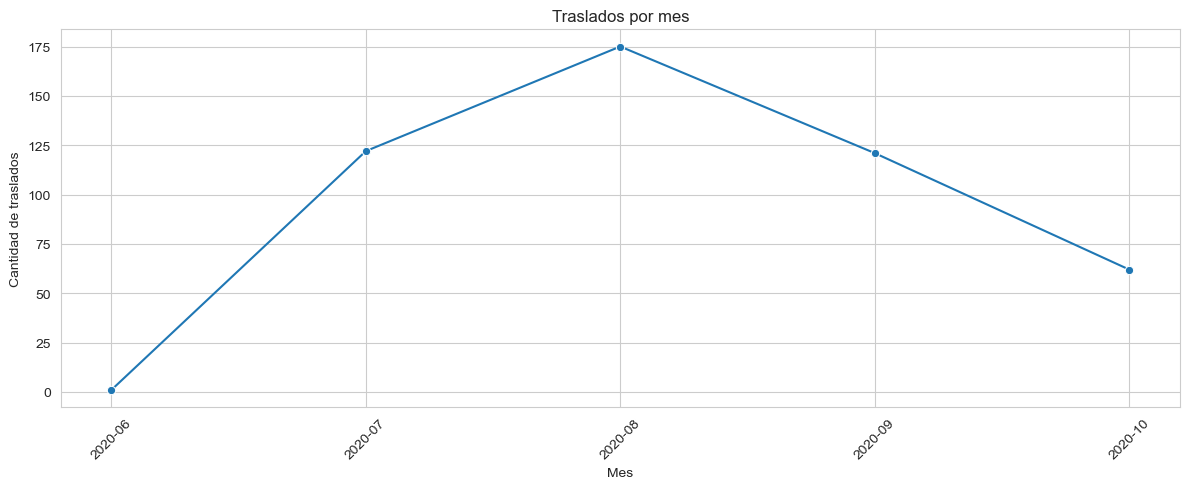

In [5]:
# Traslados por mes
_ = bases.traslados_por_mes(traslados, col_fecha="Fecha egreso", graficar=True)

## 2. Trayectorias de Paciente

### 2.1 Cantidad de traslados para cada persona (promedio y desvío, junto a distribución)

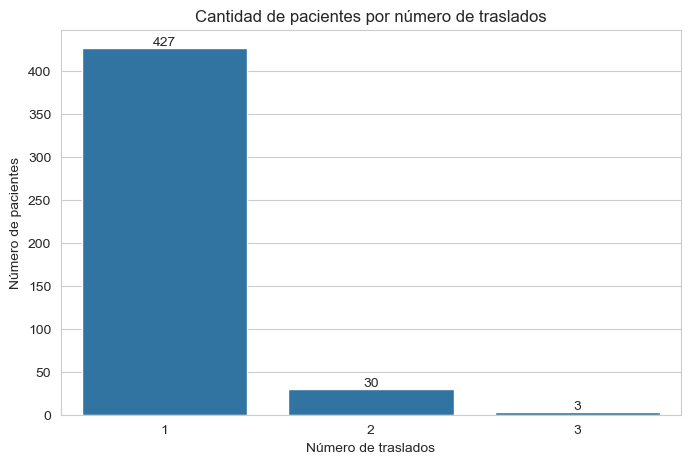

Promedio de traslados por paciente: 1.0782608695652174
Desvío estándar: 0.29217316878347316


In [6]:
# Distribución de traslados por paciente
conteo_tras_paciente, stats_tras_paciente = bases.distribucion_traslados_paciente(traslados, col_id="Id", valores=[1, 2, 3, 4, 5, 6, 7], graficar=True)

### 2.2 Tiempo dentro del sistema por persona

In [7]:
# Tiempo en el sistema por persona
tiempo_sis, limite_tiempo = bases.tiempo_total_paciente(df_pacientes, col_id="Id", col_dias="Duracion días", max_dias=100, quantile_outlier=0.99, graficar=True)

C:\Users\micag\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


## 3. Análisis Descriptivo por Hospital

### 3.1 Traslados por hospital

Top 10 hospitales que derivan más pacientes:


,traslados_out,traslados_in
UPA FV,133.0,23.0
MI PUEBLO,101.0,16.0
UPA AB,71.0,16.0
LUCIO MELENDEZ,63.0,24.0
UPA QU,28.0,5.0
MODULO HOSPITALARIO FV,26.0,210.0
ONATIVIA,20.0,2.0
IRIARTE,16.0,6.0
EL CRUCE,14.0,45.0
MODULO HOSPITALARIO QU,13.0,38.0



Top 10 hospitales que reciben más pacientes:


,traslados_out,traslados_in
MODULO HOSPITALARIO FV,26.0,210.0
MODULO HOSPITALARIO AB,10.0,110.0
EL CRUCE,14.0,45.0
MODULO HOSPITALARIO QU,13.0,38.0
LUCIO MELENDEZ,63.0,24.0
UPA FV,133.0,23.0
UPA AB,71.0,16.0
MI PUEBLO,101.0,16.0
IRIARTE,16.0,6.0
UPA QU,28.0,5.0


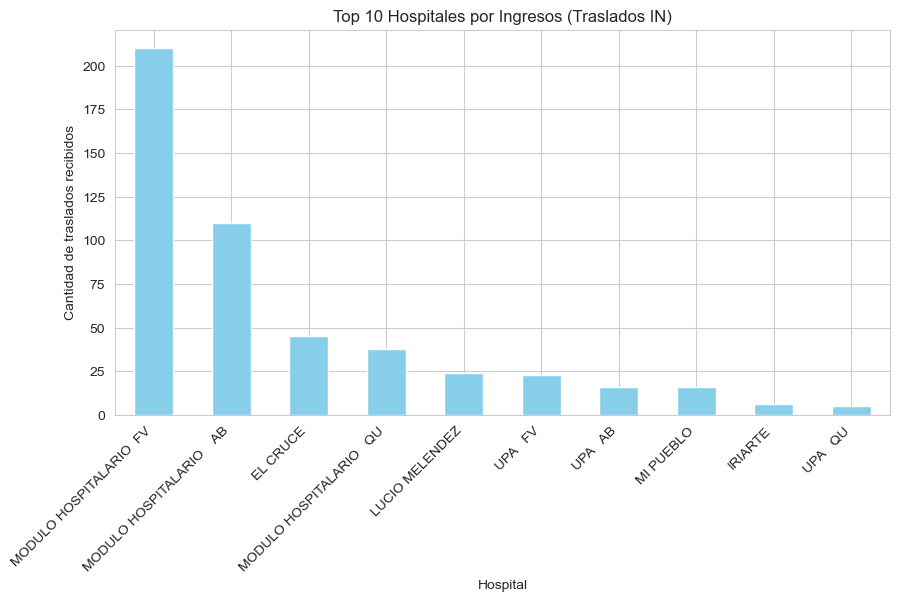

In [8]:
# Traslados OUT (Origen)
traslados_out = bases.traslados_por_hospital(traslados, col_hospital="Nombre Hospital", graficar=False)

# Traslados IN (Destino)
traslados_in = bases.traslados_por_hospital(traslados, col_hospital="Hospital siguiente", graficar=False)

tabla_hospitales = pd.DataFrame({
    "traslados_out": traslados_out,
    "traslados_in": traslados_in,
}).fillna(0)

print("Top 10 hospitales que derivan más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_out", ascending=False).head(10))

print("\nTop 10 hospitales que reciben más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_in", ascending=False).head(10))

# Graficamos los IN
tabla_hospitales["traslados_in"].sort_values(ascending=False).head(10).plot(kind="bar", color="skyblue", figsize=(10,5))
plt.title("Top 10 Hospitales por Ingresos (Traslados IN)")
plt.ylabel("Cantidad de traslados recibidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

### 3.2 Tiempo promedio que pasa una persona dentro del hospital

Nombre Hospital
IRIARTE                        14.134375
MÓDULO HOSPITALARIO 10 - QU    12.804348
MÓDULO HOSPITALARIO 11- FV     10.782730
EL CRUCE                        8.812652
OÑATIVIA                        8.767442
LUCIO MELÉNDEZ                  8.333876
MÓDULO HOSPITALARIO  9 - AB     7.873786
OLLER                           6.268817
MI PUEBLO                       5.568966
UPA 17 - QU                     3.787234
Name: Duracion días, dtype: float64

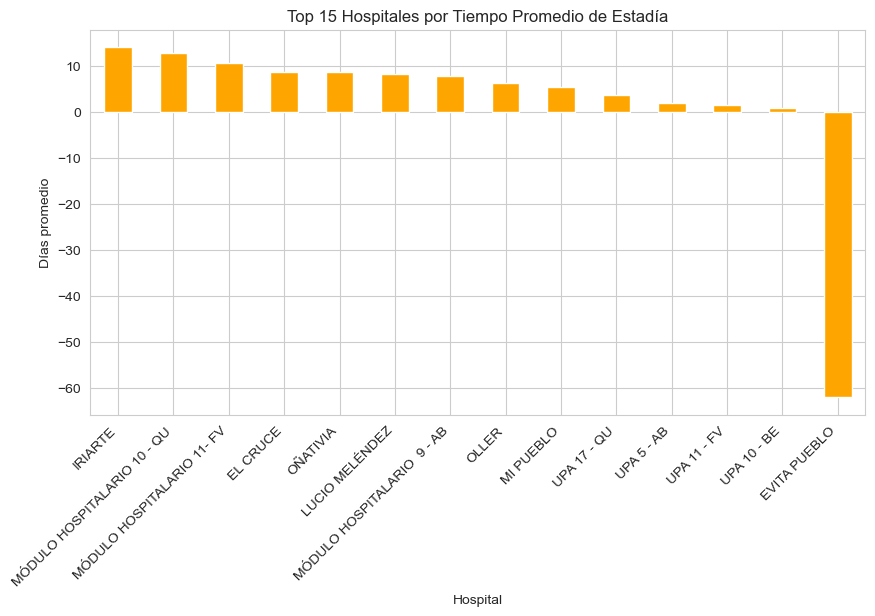

In [9]:
# Tiempo promedio por hospital
tiempo_prom_hosp = bases.tiempo_promedio_por_hospital(df_pacientes, col_hospital="Nombre Hospital", col_dias="Duracion días", quantile_outlier=0.99, graficar=False)

display(tiempo_prom_hosp.head(10))

tiempo_prom_hosp.head(15).plot(kind="bar", color="orange", figsize=(10,5))
plt.title("Top 15 Hospitales por Tiempo Promedio de Estadía")
plt.ylabel("Días promedio")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

### 3.3 Cantidad de muertos por hospital

Nombre Hospital
OÑATIVIA                       109
EVITA PUEBLO                   100
LUCIO MELÉNDEZ                  91
IRIARTE                         82
MI PUEBLO                       77
MÓDULO HOSPITALARIO 11- FV      66
EL CRUCE                        56
MÓDULO HOSPITALARIO  9 - AB     40
MÓDULO HOSPITALARIO 10 - QU     27
UPA 5 - AB                      25
dtype: int64

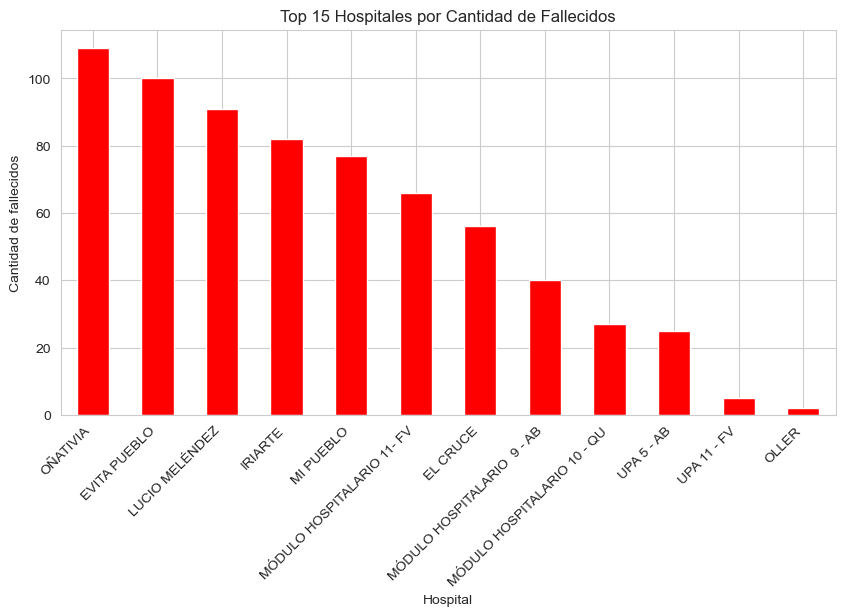

In [10]:
# Cantidad de muertos por hospital
muertes_hosp = bases.muertes_por_hospital(df_pacientes, col_hospital="Nombre Hospital", col_muerte="murio", graficar=False)

display(muertes_hosp.head(10))

muertes_hosp.head(15).plot(kind="bar", color="red", figsize=(10,5))
plt.title("Top 15 Hospitales por Cantidad de Fallecidos")
plt.ylabel("Cantidad de fallecidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

## 4. Análisis Combinado

### 4.1 Cantidad de personas con distintos niveles de riesgo social y estados (crítico, intermedio general)

In [11]:
# Tabla cruzada de Nivel de riesgo social y Estado al ingreso
if "Nivel de riesgo" in df_pacientes.columns and "Estado al ingreso" in df_pacientes.columns:
    tabla_riesgo_estado = pd.crosstab(
        df_pacientes["Nivel de riesgo"],
        df_pacientes["Estado al ingreso"],
        margins=True,
        margins_name="Total"
    )
    
    display(tabla_riesgo_estado)
    
    # Gráfico sin los totales
    tabla_sin_totales = pd.crosstab(
        df_pacientes["Nivel de riesgo"],
        df_pacientes["Estado al ingreso"]
    )
    
    tabla_sin_totales.plot(
        kind="bar", 
        stacked=False, 
        figsize=(10, 6),
        colormap="viridis"
    )
    plt.title("Estado al ingreso según Nivel de Riesgo Social")
    plt.ylabel("Cantidad de pacientes")
    plt.xlabel("Nivel de Riesgo")
    plt.xticks(rotation=0)
    plt.legend(title="Estado al ingreso")
    plt.tight_layout()
    plt.show()
else:
    print("Las columnas necesarias para este análisis no están disponibles.")
    print("Columnas disponibles:", df_pacientes.columns.tolist())

Las columnas necesarias para este análisis no están disponibles.
Columnas disponibles: ['Id Hospital', 'Nombre Hospital', 'Id', 'Fecha inicio', 'Estado al ingreso', 'Tipo al ingreso', 'Último estado', 'Último tipo', 'Sexo', 'Edad', 'Nivel riesgo clínico', 'Nivel riesgo social', 'Enfermedades preexistentes', 'Motivo', 'Operación', 'Fecha egreso', 'Última actualización', 'Duracion días', 'murio']
